In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg, col

spark = SparkSession.builder.appName("Metadata Analysis").getOrCreate()

df_pandas = pd.read_csv("combined_metadata.csv")

df_spark = spark.read.csv("combined_metadata.csv", header=True, inferSchema=True)


In [21]:
df_spark.show(5)
df_pandas.head()

+-----------+--------------------+------------------+------+--------------------+----------------+-----------+----------+----------+-------------+---------+
|         id|               title|          uploader|artist|                tags|duration_seconds|upload_date|view_count|like_count|year_uploaded|tag_count|
+-----------+--------------------+------------------+------+--------------------+----------------+-----------+----------+----------+-------------+---------+
|zjplA5XnacE|Aalote Chol - Lyr...|         SVF Music|  NULL|['svf music', 'sv...|             258|   20230105|   7469860|     58796|         2023|       30|
|gJLVTKhTnog|Anuv Jain - HUSN ...|         Anuv Jain|  NULL|                  []|             239|   20231130| 217905789|   2218168|         2023|        0|
|AGsn2ycFRqI|A.R. Rahman - Tum...|SonyMusicIndiaVEVO|  NULL|['tum tak', 'tum ...|             304|   20130805|  78932767|    518882|         2013|       23|
|RCCz1WdU-D0|Beatles | Firoze ...|       Firoze Jong|  NUL

,id,title,uploader,artist,tags,duration_seconds,upload_date,view_count,like_count,year_uploaded,tag_count
0,zjplA5XnacE,Aalote Chol - Lyrical (আলোতে চল) | Srikanto | ...,SVF Music,NaN,"['svf music', 'svf music new song', 'latest be...",258,20230105,7469860,58796,2023,30
1,gJLVTKhTnog,Anuv Jain - HUSN (Official Video),Anuv Jain,NaN,[],239,20231130,217905789,2218168,2023,0
2,AGsn2ycFRqI,A.R. Rahman - Tum Tak (Lyric Video) | Raanjhan...,SonyMusicIndiaVEVO,NaN,"['tum tak', 'tum tak song', 'tum tak lyrics', ...",304,20130805,78932767,518882,2013,23
3,RCCz1WdU-D0,Beatles | Firoze Jong,Firoze Jong,NaN,[],274,20230225,476034,8714,2023,0
4,JgDNFQ2RaLQ,Ed Sheeran - Sapphire (Official Music Video),Ed Sheeran,NaN,"['edsheeran', 'ed sheeran', 'acoustic', 'live'...",183,20250605,119657558,3425276,2025,22


In [41]:
# What is the average duration (in seconds) of all videos in the dataset?
print(df_pandas['duration_seconds'].mean())
print(df_spark.select(avg("duration_seconds")).collect()[0][0])

215.1
215.1


In [42]:
# Which uploader appears most frequently in the dataset?
print(df_pandas['uploader'].value_counts().idxmax())
print(df_spark.groupBy("uploader").count().orderBy("count", ascending=False).first())

Deluwar Hussen Tanvir
Row(uploader='Deluwar Hussen Tanvir', count=2)


In [43]:
# Which five videos have the highest number of views? List their titles and view counts.
print(df_pandas[['title', 'view_count']].nlargest(5, 'view_count'))
print(df_spark.orderBy("view_count", ascending=False).limit(5).show())

                                               title  view_count
1                  Anuv Jain - HUSN (Official Video)   217905789
4       Ed Sheeran - Sapphire (Official Music Video)   119657558
2  A.R. Rahman - Tum Tak (Lyric Video) | Raanjhan...    78932767
0  Aalote Chol - Lyrical (আলোতে চল) | Srikanto | ...     7469860
5  Gulbahar | গুলবাহার | Ishaan এর Gaan | Shuvend...     6130480
+-----------+--------------------+------------------+------+--------------------+----------------+-----------+----------+----------+-------------+---------+
|         id|               title|          uploader|artist|                tags|duration_seconds|upload_date|view_count|like_count|year_uploaded|tag_count|
+-----------+--------------------+------------------+------+--------------------+----------------+-----------+----------+----------+-------------+---------+
|gJLVTKhTnog|Anuv Jain - HUSN ...|         Anuv Jain|  NULL|                  []|             239|   20231130| 217905789|   2218168|       

In [44]:
# For each upload year, what is the average number of likes?
print(df_pandas.groupby('year_uploaded')['like_count'].mean())
print(df_spark.groupBy("year_uploaded").agg(avg("like_count").alias("avg_likes")).show())

year_uploaded
2013    5.188820e+05
2021    5.963000e+03
2022    5.000000e+00
2023    7.618927e+05
2024    3.735300e+04
2025    1.777057e+06
Name: like_count, dtype: float64
+-------------+-----------------+
|year_uploaded|        avg_likes|
+-------------+-----------------+
|         2025|        1777057.0|
|         2023|761892.6666666666|
|         2022|              5.0|
|         2013|         518882.0|
|         2024|          37353.0|
|         2021|           5963.0|
+-------------+-----------------+

None


/tmp/ipython-input-45-2464059154.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_pandas['title'], y=df_pandas['num_tags'], palette='Blues_d')


<Axes: xlabel='title', ylabel='num_tags'>

/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Matplotlib currently does not support Bengali natively.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 2507 (\N{BENGALI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 2468 (\N{BENGALI LETTER TA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 2503 (\N{BENGALI VOWEL SIGN E}) missing from font(s) DejaVu

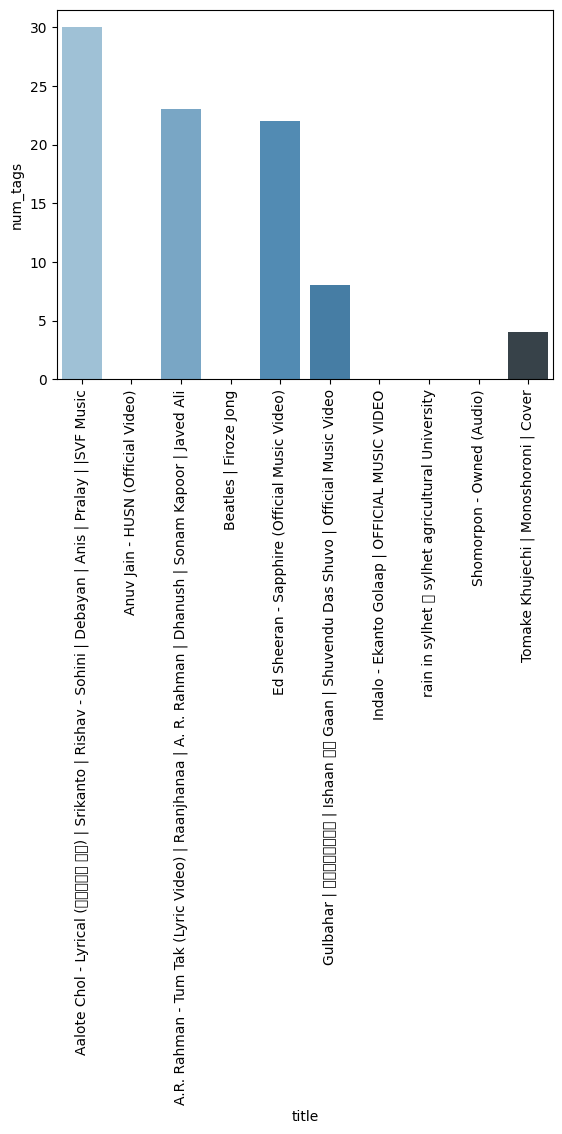

In [45]:

# Count the number of tags for each video (length of the list in 'tags' column)
df_pandas['tags'] = df_pandas['tags'].apply(lambda x: eval(x) if isinstance(x, str) else [])
df_pandas['num_tags'] = df_pandas['tags'].apply(len)
plt.xticks(rotation=90)
sns.barplot(x=df_pandas['title'], y=df_pandas['num_tags'], palette='Blues_d')

In [46]:
# What is the total number of views per uploader? Rank the results in descending order.
print(df_pandas.groupby('uploader')['view_count'].sum().sort_values(ascending=False))

uploader
Anuv Jain                217905789
Ed Sheeran               119657558
SonyMusicIndiaVEVO        78932767
SVF Music                  7469860
Ishaan                     6130480
Indalo                     2426631
Owned The Band              537761
Firoze Jong                 476034
Deluwar Hussen Tanvir          313
Name: view_count, dtype: int64


In [47]:
# Which video has the longest duration? List the title and its duration.
print(df_pandas.loc[df_pandas['duration_seconds'].idxmax()][['title', 'duration_seconds']])

title               A.R. Rahman - Tum Tak (Lyric Video) | Raanjhan...
duration_seconds                                                  304
Name: 2, dtype: object


In [48]:
# How many videos were uploaded in each year? Present the results sorted by year.
print(df_pandas['year_uploaded'].value_counts().sort_values(ascending=True))

year_uploaded
2013    1
2024    1
2022    1
2025    2
2021    2
2023    3
Name: count, dtype: int64


In [52]:
# Is there a correlation between the number of views and the number of likes? Feel free to drop or filter rows with missing or zero values before computing correlation
df_pandas = df_pandas.dropna()
df_pandas = df_pandas[df_pandas['view_count'] > 0]
df_pandas = df_pandas[df_pandas['like_count'] > 0]
correlation = df_pandas['view_count'].corr(df_pandas['like_count'])
print(correlation)


nan


In [49]:
# Which video has the highest number of likes per second of duration?
df_pandas['likes_per_second'] = df_pandas['like_count'] / df_pandas['duration_seconds']
video_with_highest_likes_per_second = df_pandas.loc[df_pandas['likes_per_second'].idxmax()]
print(video_with_highest_likes_per_second)

id                                                        JgDNFQ2RaLQ
title                    Ed Sheeran - Sapphire (Official Music Video)
uploader                                                   Ed Sheeran
artist                                                            NaN
tags                [edsheeran, ed sheeran, acoustic, live, cover,...
duration_seconds                                                  183
upload_date                                                  20250605
view_count                                                  119657558
like_count                                                    3425276
year_uploaded                                                    2025
tag_count                                                          22
num_tags                                                           22
likes_per_second                                         18717.355191
Name: 4, dtype: object


In [50]:
# Which uploader has the longest total duration of all their uploaded videos combined?
uploader_total_duration = df_pandas.groupby('uploader')['duration_seconds'].sum()
longest_uploader = uploader_total_duration.idxmax()
print(longest_uploader)

SonyMusicIndiaVEVO


In [51]:
# What is the ratio of views to likes for each video?
df_pandas['view_like_ratio'] = df_pandas['view_count'] / df_pandas['like_count']
print(df_pandas[['title', 'view_like_ratio']])

                                               title  view_like_ratio
0  Aalote Chol - Lyrical (আলোতে চল) | Srikanto | ...       127.047078
1                  Anuv Jain - HUSN (Official Video)        98.236828
2  A.R. Rahman - Tum Tak (Lyric Video) | Raanjhan...       152.120843
3                              Beatles | Firoze Jong        54.628644
4       Ed Sheeran - Sapphire (Official Music Video)        34.933698
5  Gulbahar | গুলবাহার | Ishaan এর Gaan | Shuvend...        47.582856
6      Indalo - Ekanto Golaap | OFFICIAL MUSIC VIDEO        64.964822
7    rain in sylhet । sylhet agricultural University         9.666667
8                          Shomorpon - Owned (Audio)        45.114178
9              Tomake Khujechi | Monoshoroni | Cover        51.000000


In [35]:
# How many videos are missing artist information?
missing_artist_count = df_pandas['artist'].isnull().sum()
print(missing_artist_count)
print(df_spark.filter(col("artist").isNull()).count())

10
10
